In [230]:
#imports
import sys
sys.path.append("../../src")
# A collection of handy imports. Not that important.
from project_imports import * 
import numerical_quenches as nq
from numerical_quenches import g_linear_hold

import TFIM_operators_from_states as op


In [3]:
#Critical Times of DQPTs
def critical_times(gf,n):
    ek = 2*sqrt(gf**2+1)
    n_plot = np.arange(0,n)
    tns = (n_plot+1/2)*pi/ek
    return tns
def est_z_defects(tau,n):
    numerator = n*n+n
    denom = 2**(n-1)*4*pi*sqrt(2*tau)
    return numerator/denom
def est_x_defects(tau,n):
    numerator = n-1
    denom = 4*pi*sqrt(2*tau)
    return numerator/denom


In [513]:
###
#Params
###
L=100 #Length
g0 = 2 #Initial Field
gf = 0.0 #Final Field
quench_times = np.logspace(-2,2,60)

#####

t_c = critical_times(gf,1)[0] #DQPT timescale from sudden quench. t_c(2n+1) mark the LE non-analytic cusps



In [514]:

#masks = [(t_plot >= 0) & (t_plot <= ti ) for ti in t_cutoffs] #If the old one is unececssary so is this

slow_protocol_states=[]
#Main Loop
for quench_time in quench_times:
    ####g= 1- t/tau
    t_start = quench_time*(1-g0)
    t_quench_end = quench_time*(1-gf)

    t_quench_evolution= np.linspace(t_start,t_quench_end,25,endpoint=False)
    t_free_evolution = np.linspace(t_quench_end,t_quench_end+t_c*10,200)
    t_eval = np.concatenate((t_quench_evolution ,t_free_evolution  ))
    t_plot = (t_eval -t_quench_end)

    slow_args = [quench_time,t_quench_end]
    #Generate States
    print(quench_time)
    slow_states = nq.states(L,t_eval,g_linear_hold,slow_args)

    #Appending
    slow_protocol_states.append(slow_states)
#Now we have all the states.




0.01
g0=2.0
0.011689518164985783
g0=2.0
0.013664483492953258
g0=2.0
0.01597312280060254
g0=2.0
0.018671810912919196
g0=2.0
0.021826447283974874
g0=2.0
0.025514065200312887
g0=2.0
0.02982471286216891
g0=2.0
0.03486365227678084
g0=2.0
0.040753929658717776
g0=2.0
0.047639380104013404
g0=2.0
0.0556881399094527
g0=2.0
0.0650967523045817
g0=2.0
0.07609496685459875
g0=2.0
0.08895134973108236
g0=2.0
0.103979841848149
g0=2.0
0.12154742500762866
g0=2.0
0.14208308325339222
g0=2.0
0.1660882782627716
g0=2.0
0.19414919457438806
g0=2.0
0.22695105366946683
g0=2.0
0.26529484644318957
g0=2.0
0.3101168926574778
g0=2.0
0.3625117049988533
g0=2.0
0.4237587160604063
g0=2.0
0.495353520895917
g0=2.0
0.5790443980602487
g0=2.0
0.6768750009458534
g0=2.0
0.7912342618981323
g0=2.0
0.9249147277217336
g0=2.0
1.0811807510766078
g0=2.0
1.2638482029342986
g0=2.0
1.4773776525985112
g0=2.0
1.7269832906594342
g0=2.0
2.018760254679039
g0=2.0
2.359833466782194
g0=2.0
2.7585316176291843
g0=2.0
3.2245905452963948
g0=2.0
3.7693

In [515]:
ns=[2,3,4,5,6]

ALLX=nq.groundstate(0,L)


2.0416742350486892e-19


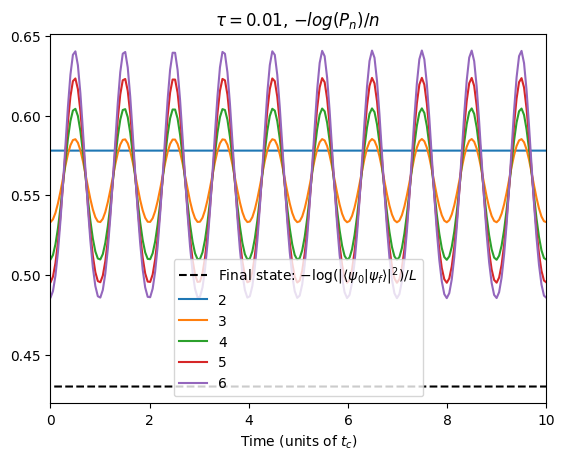

2.0529362951272632e-19


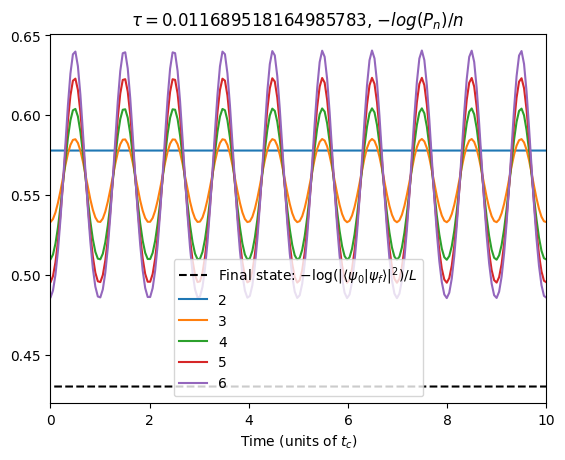

2.0684196194056641e-19


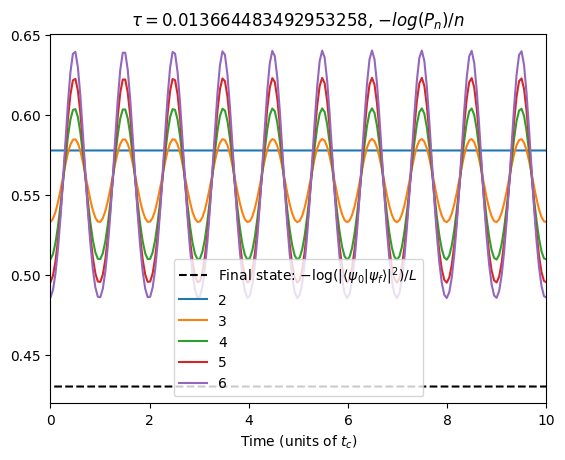

2.089754060036602e-19


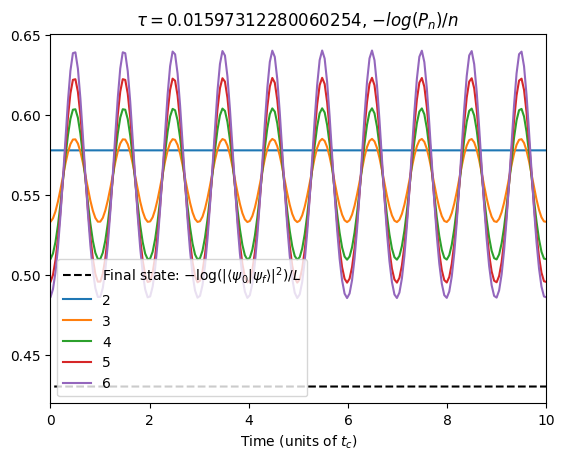

2.1192405710969616e-19


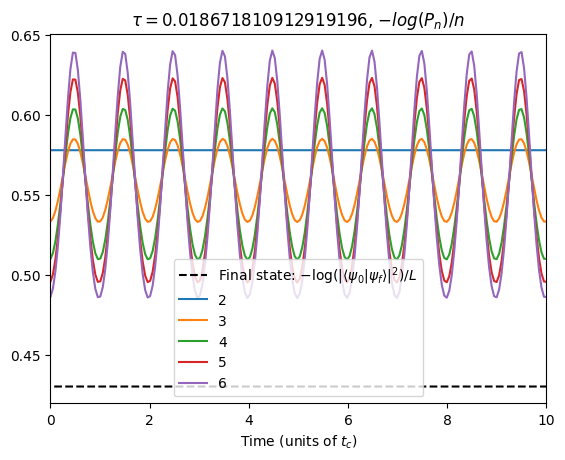

2.1601641331798e-19


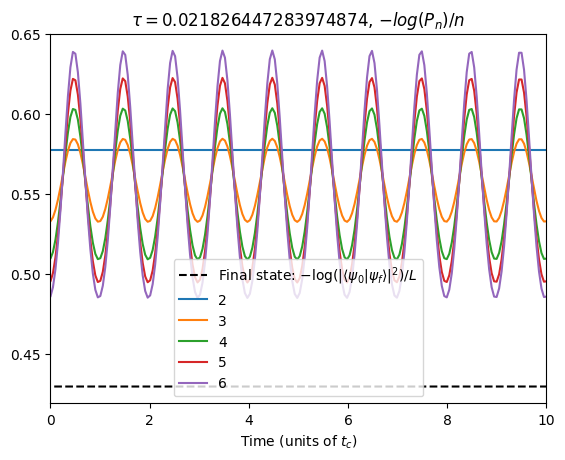

2.2172842811191464e-19


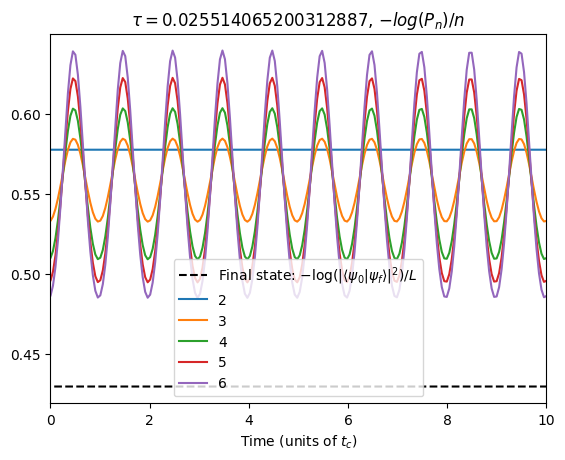

2.297630537981415e-19


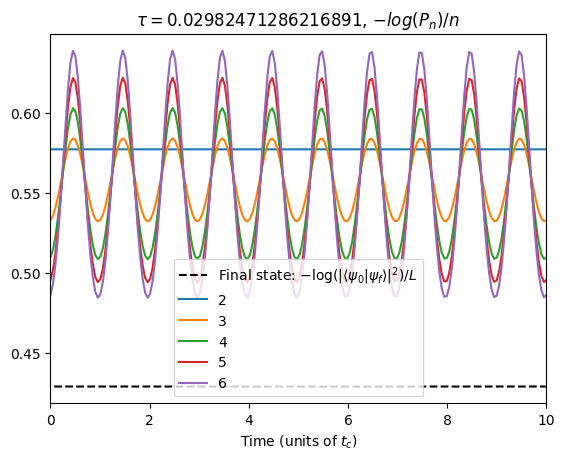

2.4118440413876234e-19


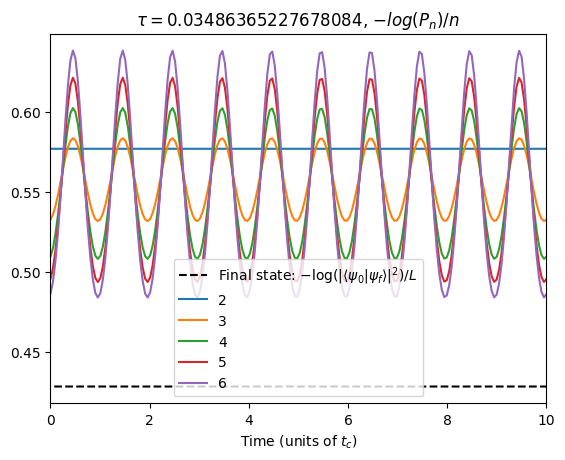

2.5765428375403562e-19


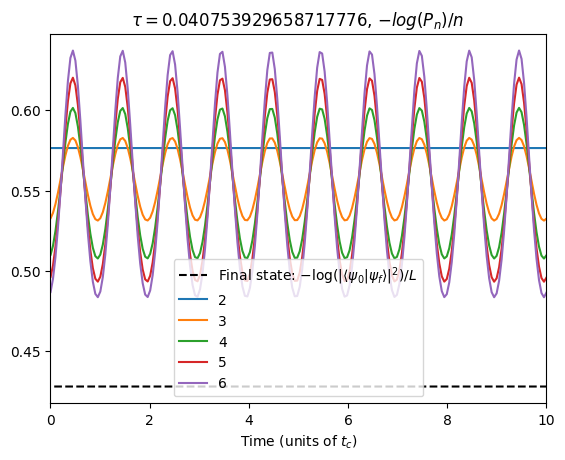

2.818705578187347e-19


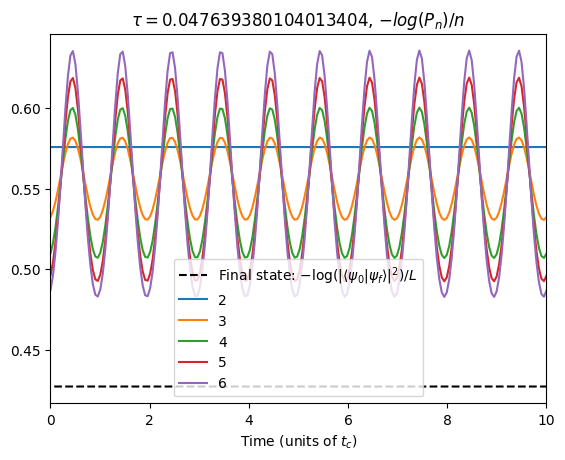

3.184263367322538e-19


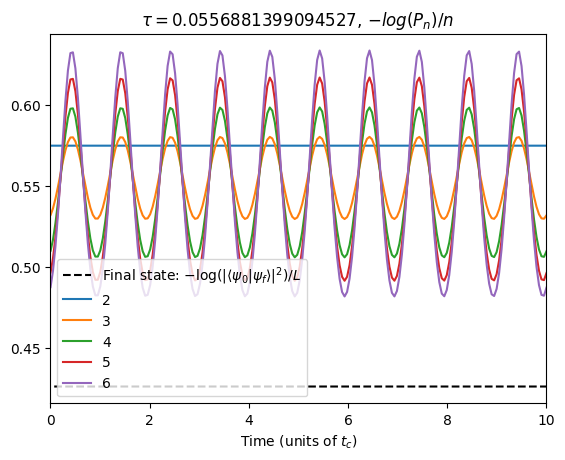

3.7560434403955625e-19


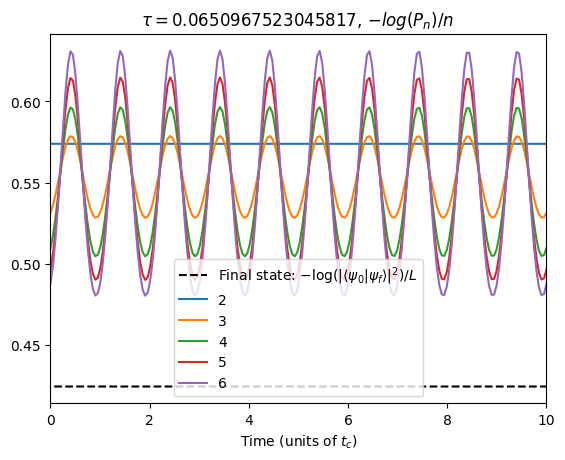

4.694069863229611e-19


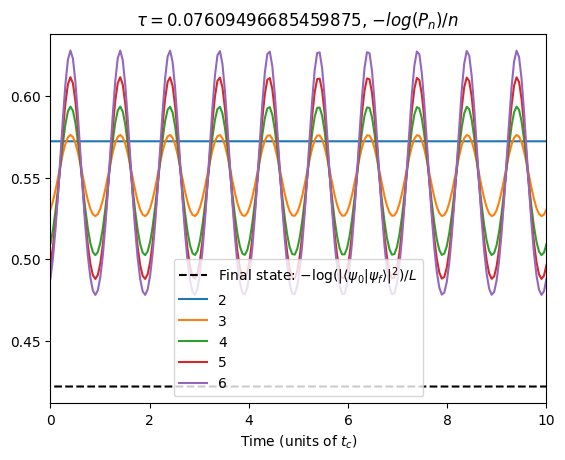

6.334041050684934e-19


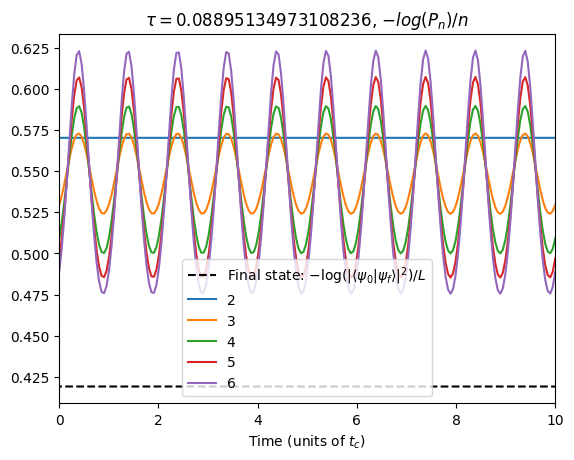

9.452915526061765e-19


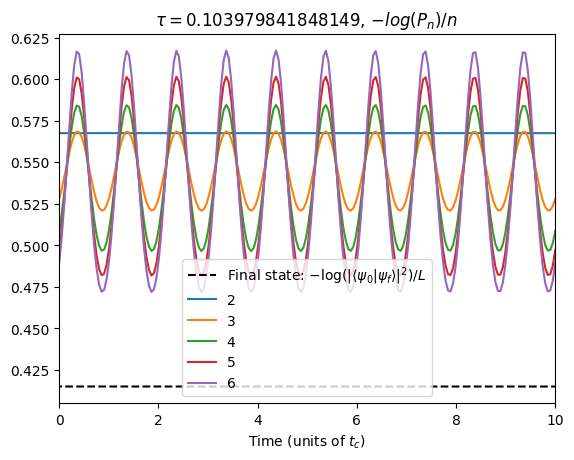

1.6073202251304347e-18


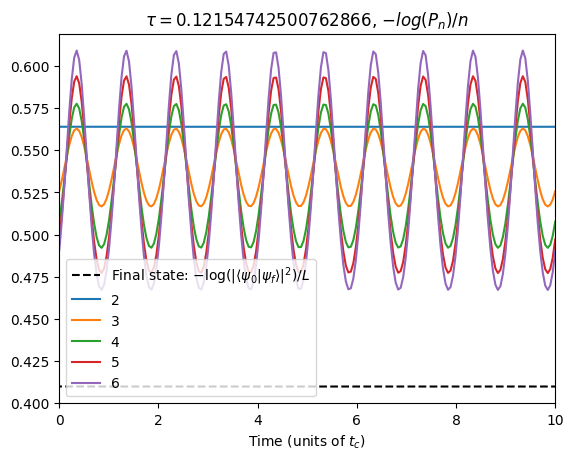

3.2253878847464124e-18


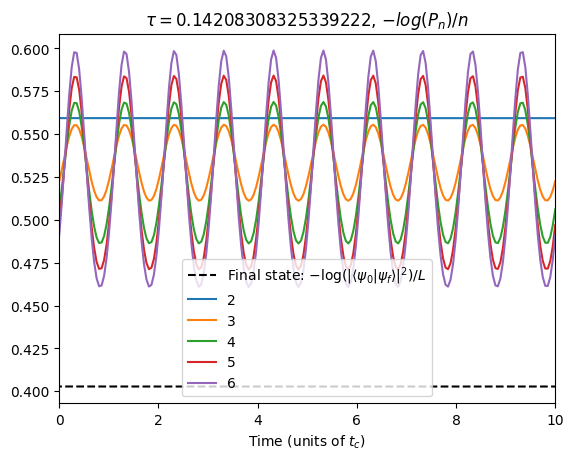

7.944189922050914e-18


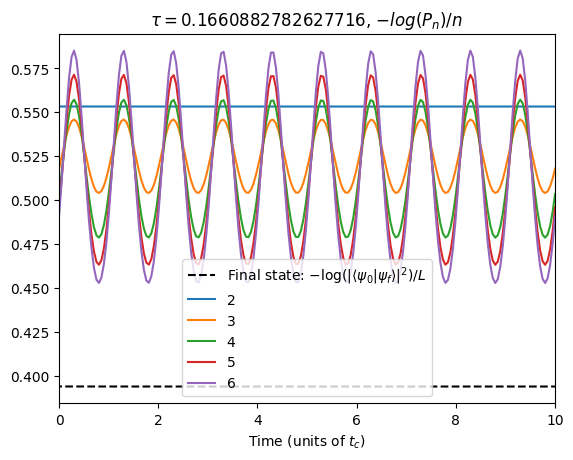

2.498748152920817e-17


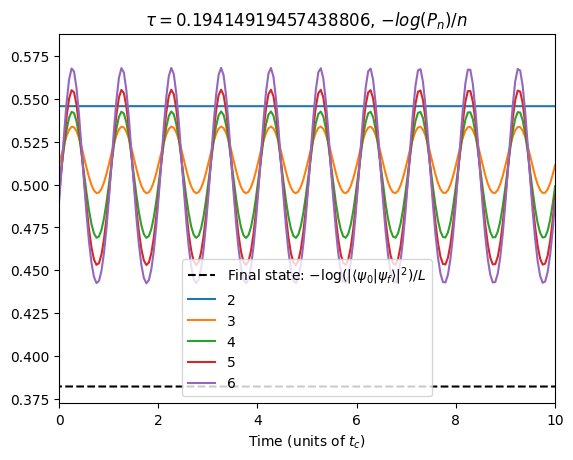

1.0377865583782317e-16


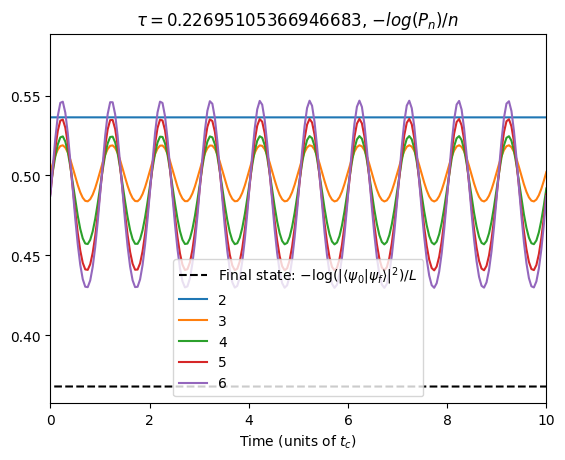

5.790895034409824e-16


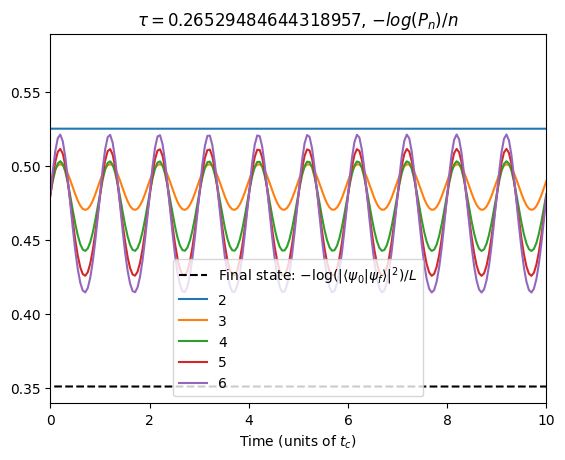

4.297733950918152e-15


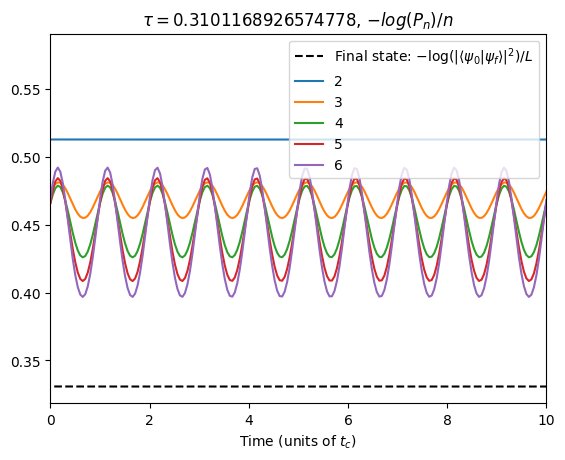

4.0508399301900855e-14


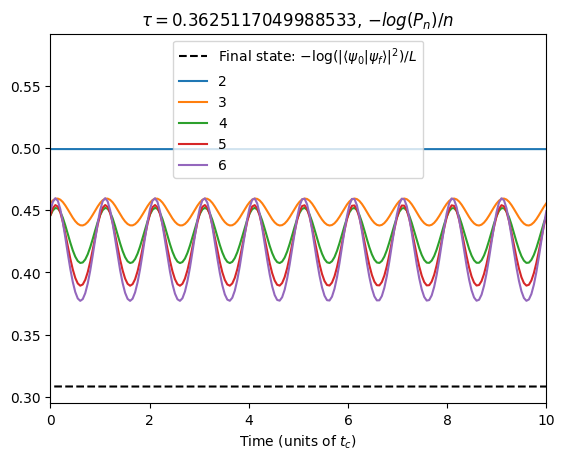

4.4755680496928645e-13


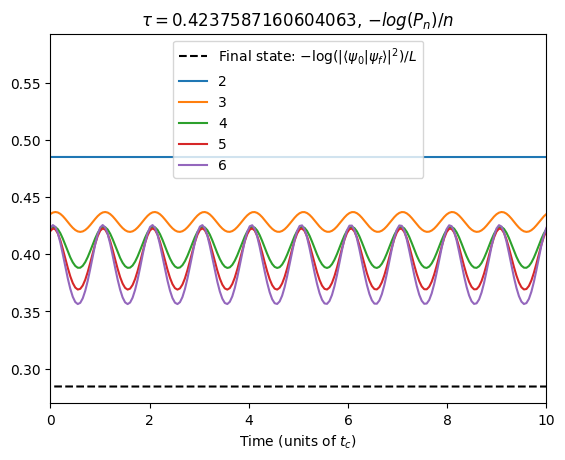

5.273906275387898e-12


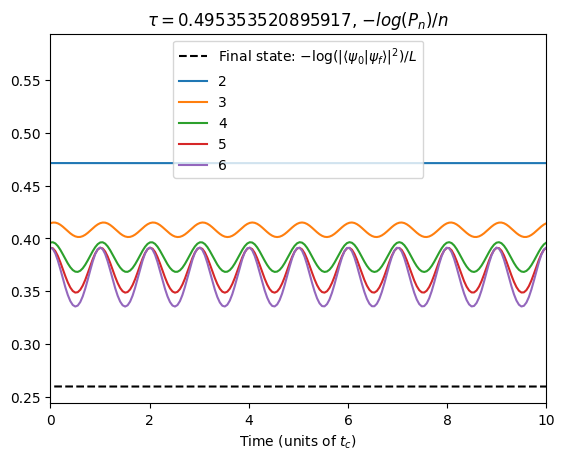

6.144361627264167e-11


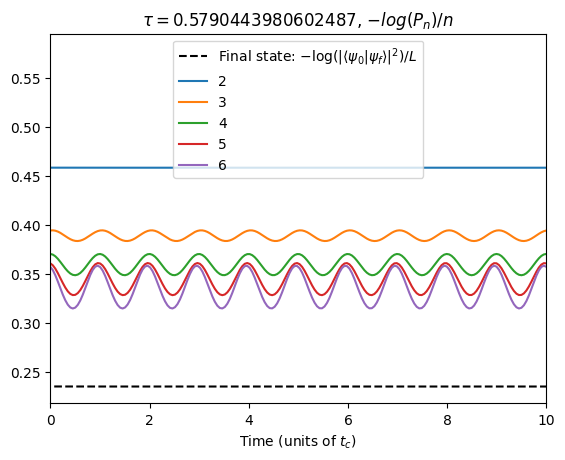

6.799303045902282e-10


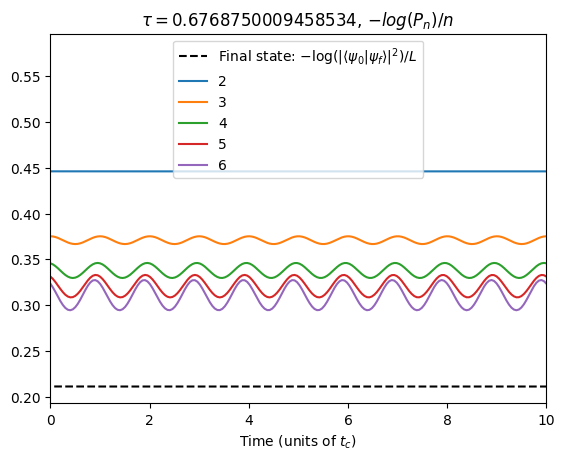

6.893268524456861e-09


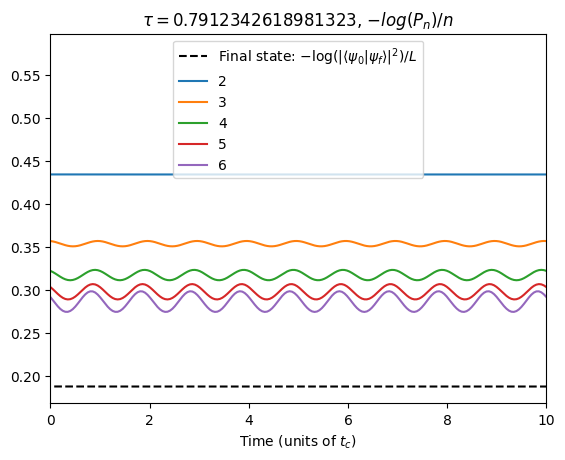

5.972074499381774e-08


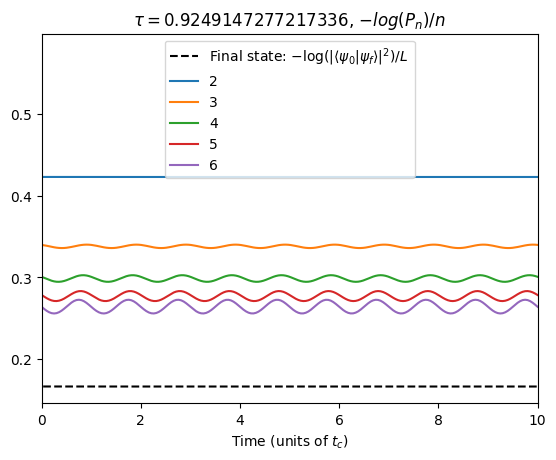

4.1775801438005256e-07


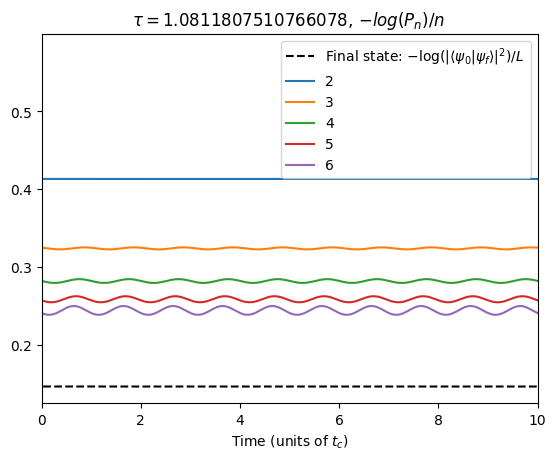

2.3092395295296764e-06


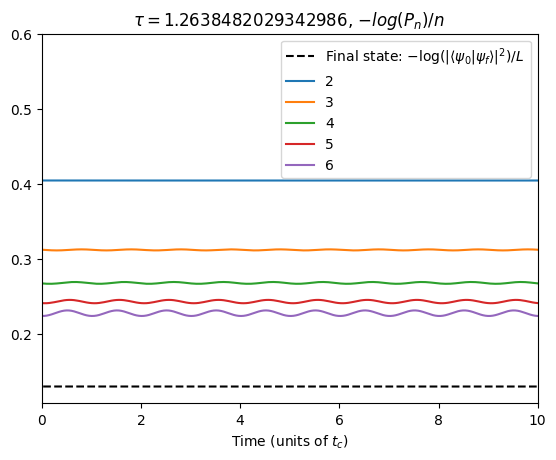

9.69144459042428e-06


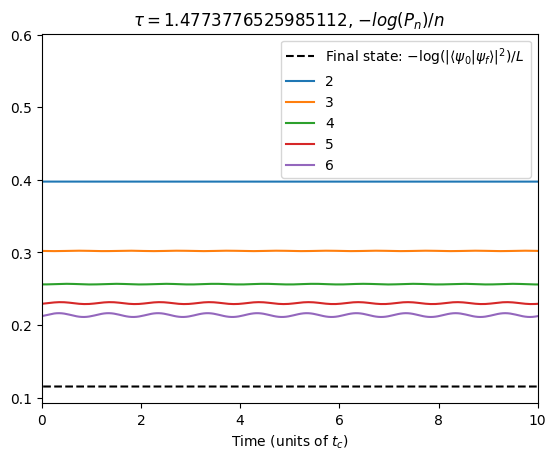

3.066615487863375e-05


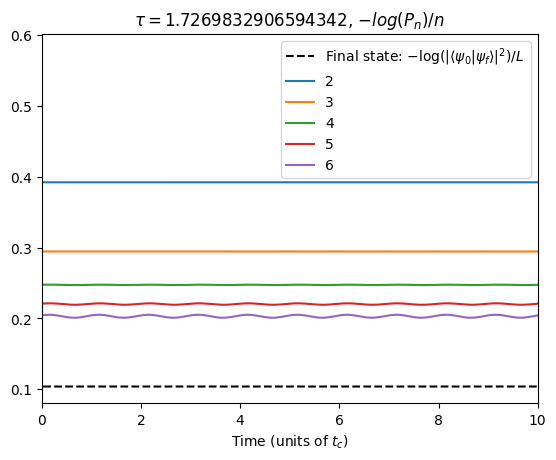

7.47037363016772e-05


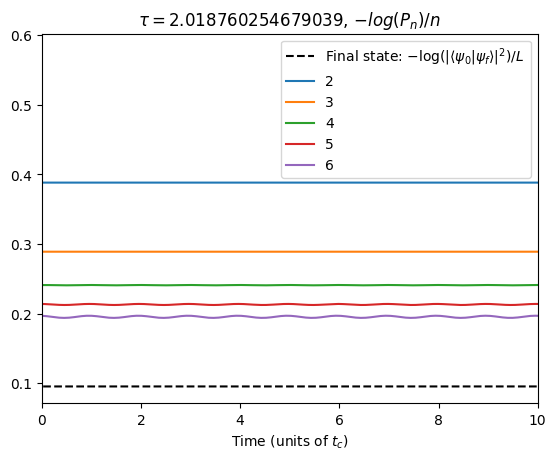

0.00014941582804588006


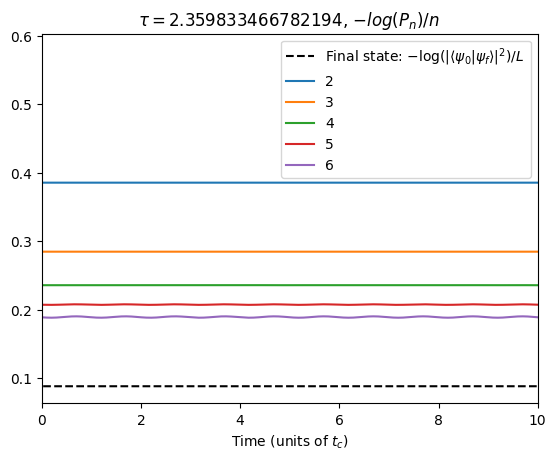

0.0002613429498910291


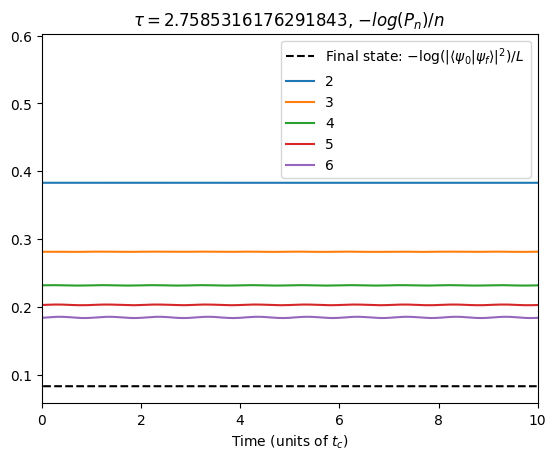

0.00044681135480263836


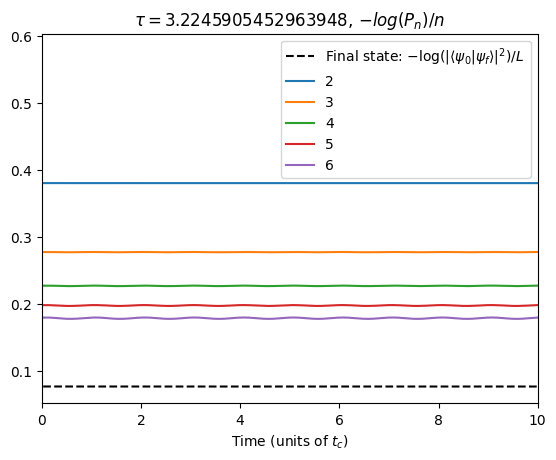

0.0008813351587116028


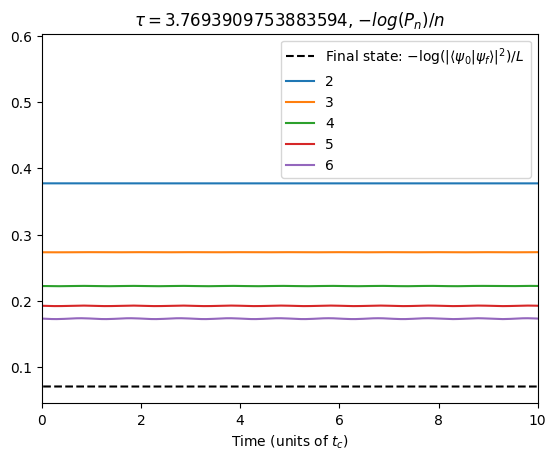

0.0017753228236753874


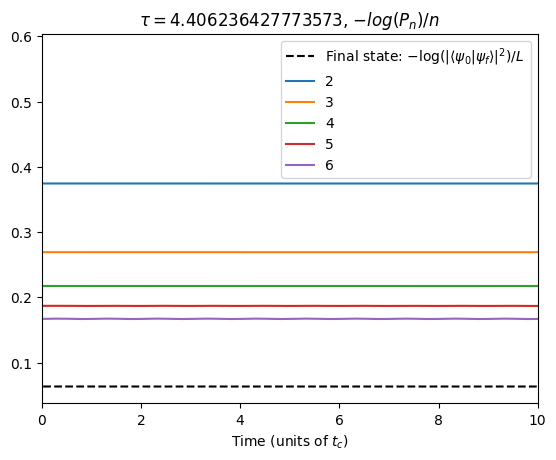

0.0031092613990002667


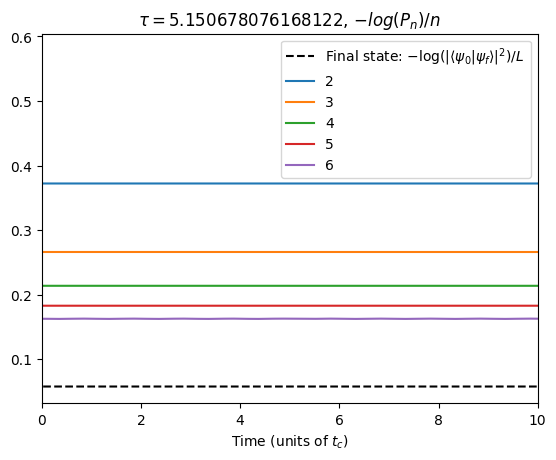

0.004739343991726703


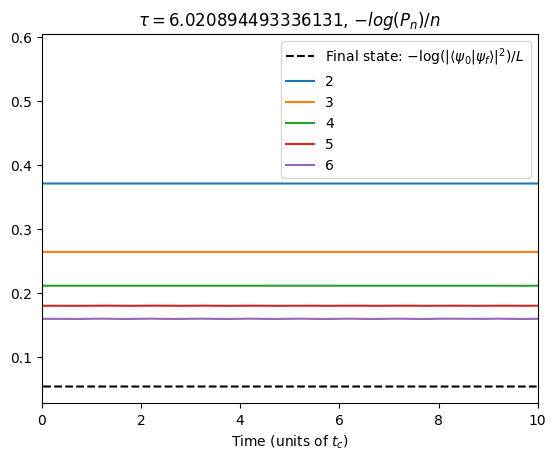

0.00755024133144608


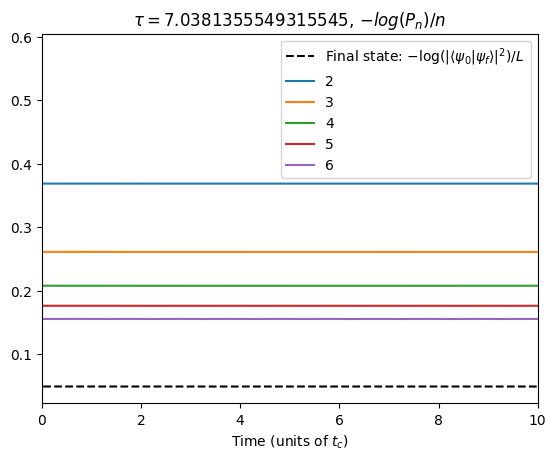

0.011905363824144902


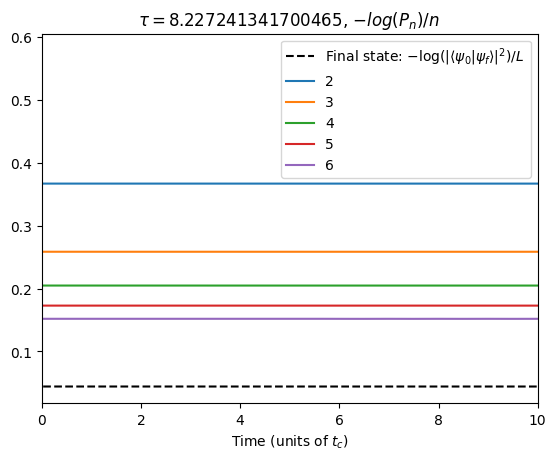

0.016960288492235576


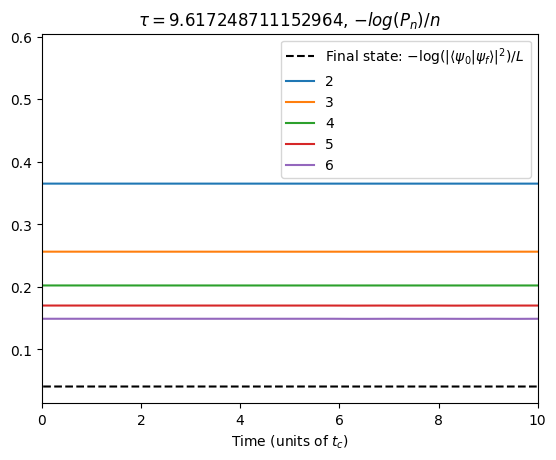

0.02493706972704748


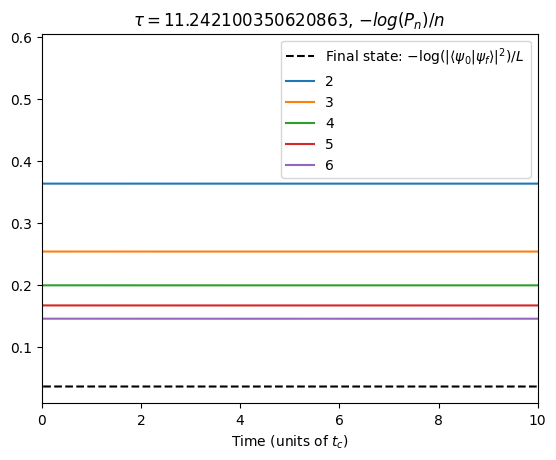

0.03418854045469644


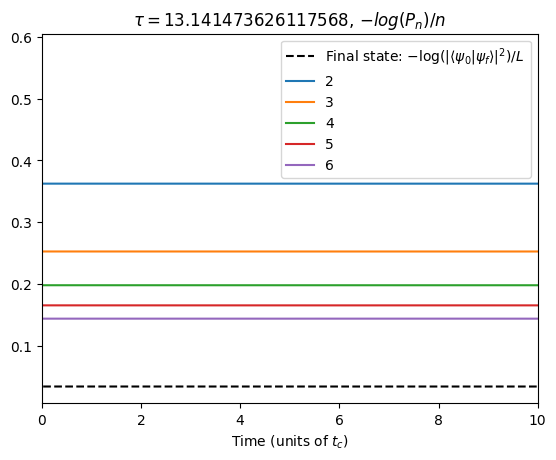

0.04654646662369917


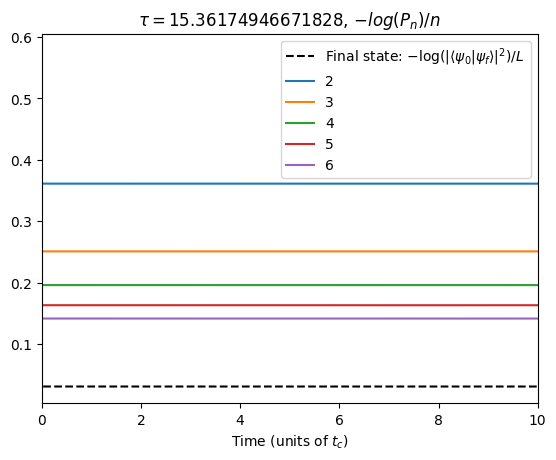

0.06208612686412227


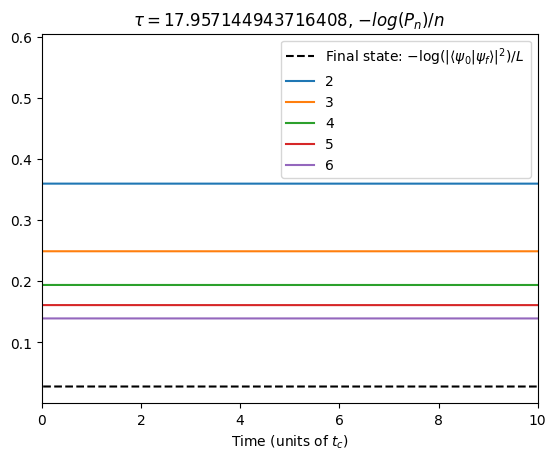

0.0806658648476527


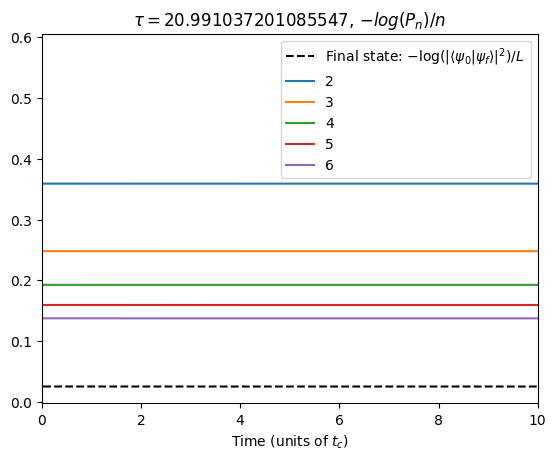

0.1025054123251495


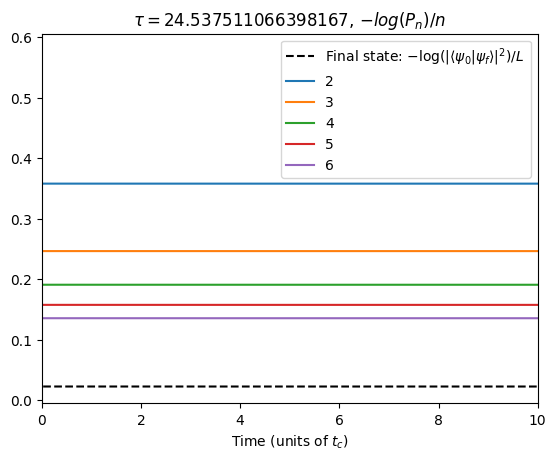

0.12805150666075385


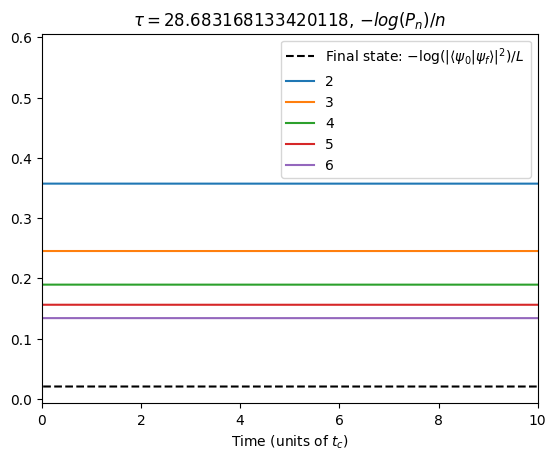

0.1577633086927348


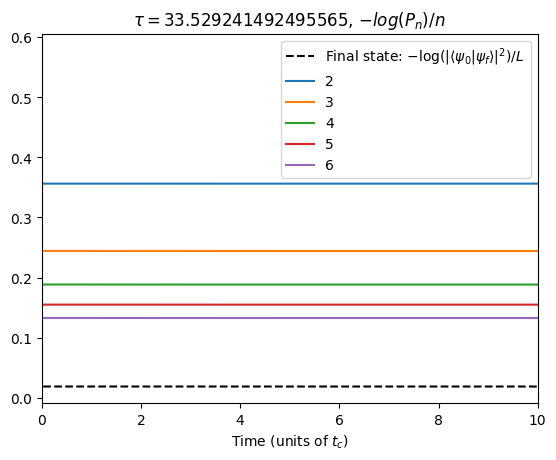

0.19097811037445023


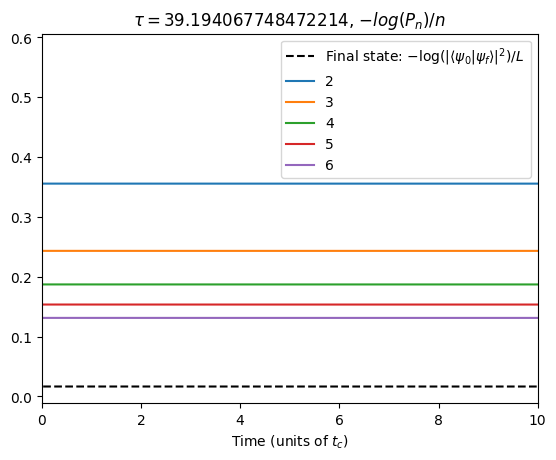

0.2278003224082874


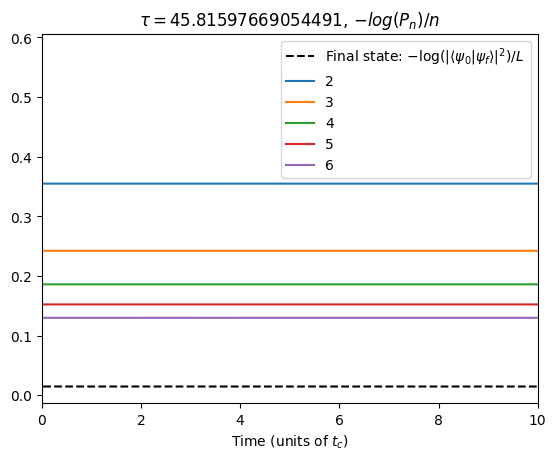

0.2679653830177593


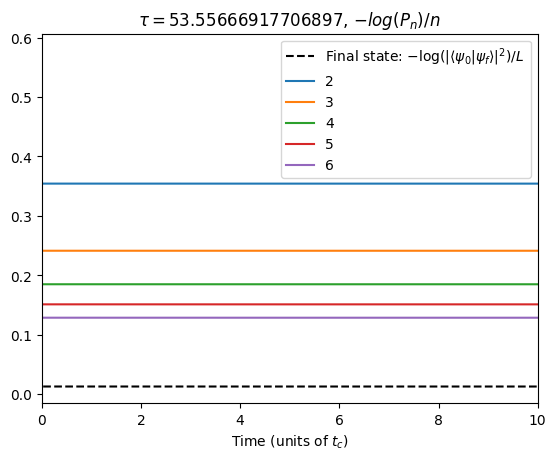

0.3116690932738142


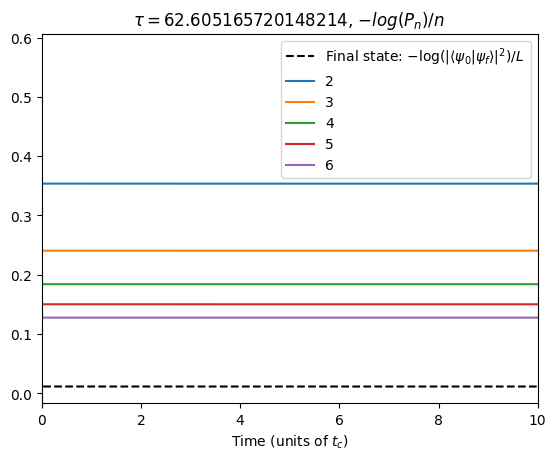

0.35845476593532205


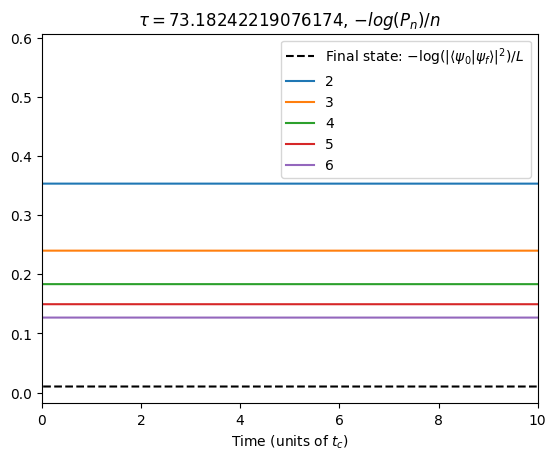

0.4080047265714232


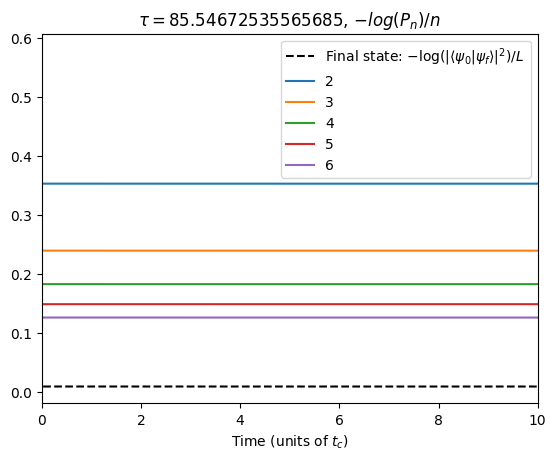

0.46019511169238375


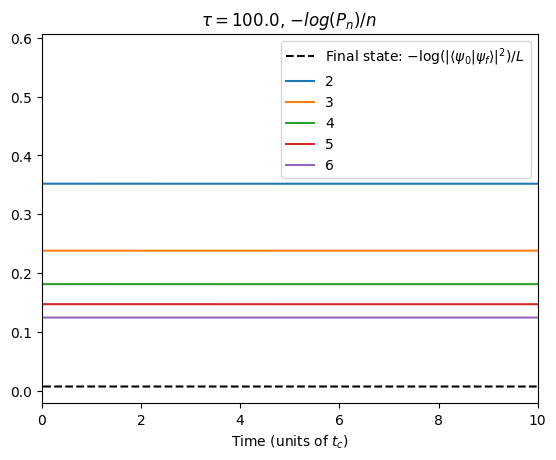

In [540]:
avgs=[]
rs=[]
x1,x2,x3,x4,x5=[],[],[],[],[]
for tau,state in zip(quench_times,slow_protocol_states):
    r=(nq.overlap(state,ALLX))
    print(max(r))
    rs.append(r)
    avgs.append(np.average(r[t_plot>0]))
    y1=array([op.Px_n(2,s) for s in state])
    y2=array([op.Px_n(3,s) for s in state])
    y3=array([op.Px_n(4,s) for s in state])
    y4=array([op.Px_n(5,s) for s in state])
    y5=array([op.Px_n(6,s) for s in state])
    x1.append( y1)
    x2.append( y2)
    x3.append( y3)
    x4.append( y4)
    x5.append(y5 )

    plot(t_plot/t_c,-log(r)/L,"--k",label=r"Final state: $-\log(|\langle \psi_0 | \psi_f \rangle|^2)/L$ " )
    plot(t_plot/t_c,-log(y1)/2,label=2  )
    plot(t_plot/t_c,-log(y2)/3,label=3  )
    plot(t_plot/t_c,-log(y3)/4 ,label=4 )
    plot(t_plot/t_c,-log(y4)/5 ,label=5 )
    plot(t_plot/t_c,-log(y5)/6 ,label=6 )

    #plot(t_plot,-log(x2)/3)
    title(fr"$\tau=${tau}, $ -log(P_n)/n$ ")
    xlabel(r"Time (units of $t_c$)")
    xlim(0,t_plot[-1]/t_c)
    legend()
    #yscale("log")
    show()

[]

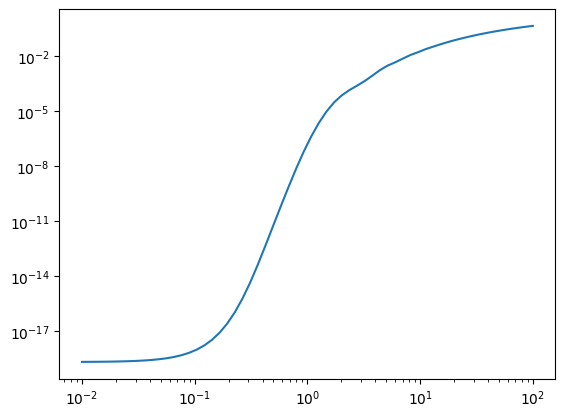

In [517]:
plot(quench_times,avgs)


loglog()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_35511/1490778345.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


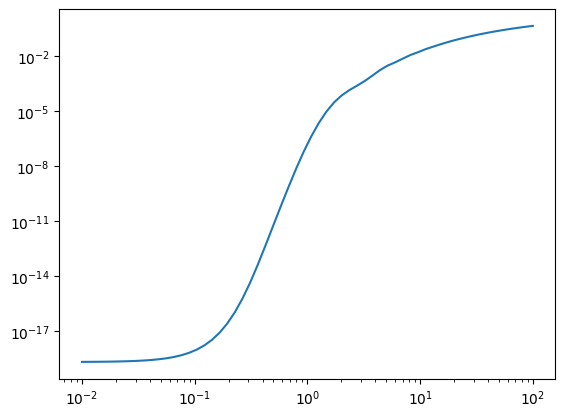

In [518]:
import numpy as np
from scipy.optimize import curve_fit

# sigmoid in log(tau)
def sigmoid_logtau(tau, ymin, ymax, k, tau0):
    return ymin*0 + (ymax - ymin*0) / (1 + np.exp(-k * (log(tau) - log(tau0))))

# initial guesses (important)
ymin0 = np.min(avgs)
ymax0 = np.max(avgs)
tau0_0 = quench_times[np.argmin(np.abs(avgs - 0.5*(ymin0+ymax0)))]
k0 = 1.0

p0 = (ymin0, ymax0, k0, tau0_0)

popt, pcov = curve_fit(
    sigmoid_logtau,
    quench_times,
    avgs,
    p0=p0
)

ymin, ymax, k, tau0 = popt

#scatter(quench_times,sigmoid_logtau(quench_times,ymin,ymax,k,tau0))
plot(quench_times,avgs)
#scatter(quench_times,quench_times**(-8)/(L*L*L))
#ylim(10e-30,.5)
yscale("log")
xscale("log")

In [519]:
r_avg=[]
r_var=[]
x1_avg=[]
x1_var=[]
x2_avg=[]
x2_var=[]
x3_avg=[]
x3_var=[]
x4_avg=[]
x4_var=[]
x5_avg=[]
x5_var=[]

for r,a,y1,y2,y3,y4,y5 in zip(rs,avgs,x1,x2,x3,x4,x5):
    r = array(r)
    rate=-log(r)/L
    rate_avg = np.average(rate[t_plot>0])
    r_avg.append(rate_avg)
    r_var.append(np.var(rate[t_plot>0]))

    prate= -log(y1)/2
    pavg = np.average(prate[t_plot>0])
    x1_avg.append(pavg)
    x1_var.append(np.var(prate[t_plot>0]))


    prate= -log(y2)/3
    pavg = np.average(prate[t_plot>0])
    x2_avg.append(pavg)
    x2_var.append(np.var(prate[t_plot>0]))


    prate= -log(y3)/4
    pavg = np.average(prate[t_plot>0])
    x3_avg.append(pavg)
    x3_var.append(np.var(prate[t_plot>0]))


    prate= -log(y4)/5
    pavg = np.average(prate[t_plot>0])
    x4_avg.append(pavg)
    x4_var.append(np.var(prate[t_plot>0]))


    prate= -log(y5)/6
    pavg = np.average(prate[t_plot>0])
    x5_avg.append(pavg)
    x5_var.append(np.var(prate[t_plot>0]))


    

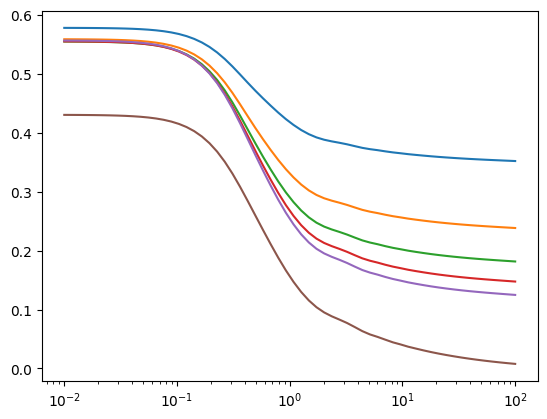

In [520]:
plot(quench_times,array(x1_avg))
plot(quench_times,array(x2_avg))
plot(quench_times,array(x3_avg))
plot(quench_times,array(x4_avg))
plot(quench_times,array(x5_avg))

plot(quench_times,r_avg)


xscale("log")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_35511/498365824.py:14: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,.2)


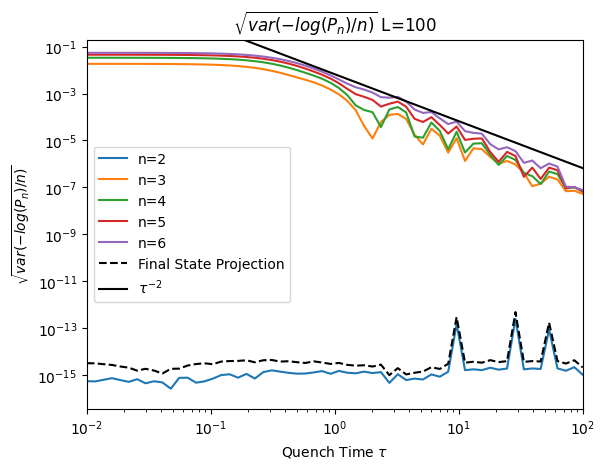

In [534]:
plot(quench_times,sqrt(array(x1_var)),label="n=2" )

plot(quench_times,sqrt(array(x2_var)),label="n=3")
plot(quench_times,sqrt(array(x3_var)),label="n=4")
plot(quench_times,sqrt(array(x4_var)),label="n=5")
plot(quench_times,sqrt(array(x5_var)),label="n=6")

plot(quench_times,sqrt(array(r_var)),"--k",label=r"Final State Projection")
plot(quench_times,quench_times**(-2)/150,color="black",label=r"$\tau^{-2}$")
loglog()
legend()

xscale("log")
ylim(0,.2)
ylabel(r"$\sqrt{var( -log(P_n)/n ) }$")
title(r"$\sqrt{var( -log(P_n)/n )} $"+f" L={L}")
xlim(quench_times[0],quench_times[-1])
xlabel(r"Quench Time $\tau$")

u = quench_times

#plot(u,u**-2/100,color="black")

(0.6, 0.8)

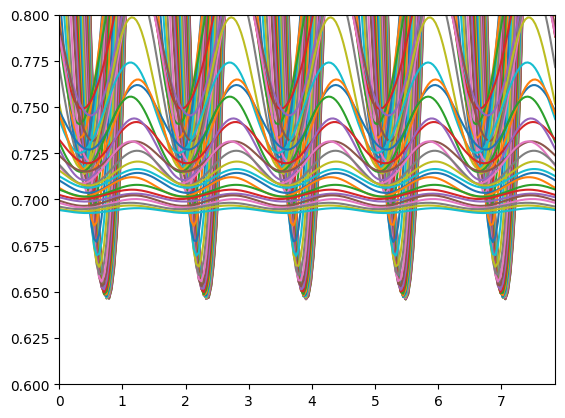

In [531]:
us= [1 for i in range(L//2)]
vs =[0 for i in range(L//2)]
ks = nq.groundstate(0,L)[-1]

s = [us,vs,ks]

for si in slow_protocol_states:
    plot(t_plot,-log(nq.overlap(si,s))/L)
xlim(0,t_plot[-1])
ylim(.6,.8)